In [1]:
import json, polars as pl
from pathlib import Path
from IPython.display import Image, Markdown, display
ROOT = Path.cwd().parent
T = ROOT / "reports" / "tables"; F = ROOT / "reports" / "figures"
pl.Config.set_tbl_rows(40); pl.Config.set_tbl_cols(20); pl.Config.set_tbl_width_chars(200)
def show(p): display(Image(filename=str(p)))
def tab(p, cols=None):
    d = pl.read_csv(p); return d.select(cols) if cols else d

# 05 · Models
Logistic regression (L2), random forest, LightGBM, plus rule baselines scored as classifiers.

In [2]:
tab(T / 'lgbm_tuning.csv')

grid_id,num_leaves,min_child_samples,n_estimators,mean_log_loss,sd_log_loss,mean_auc,sd_auc,min_auc,mean_ll_improvement
i64,i64,i64,i64,f64,f64,f64,f64,f64,f64
0,15,500,200,0.691125,0.001153,0.538777,0.008378,0.528411,0.001956
2,15,5000,200,0.691152,0.001261,0.53849,0.008648,0.527662,0.001929
6,63,5000,200,0.691226,0.001267,0.538166,0.008448,0.528189,0.001855
1,15,500,600,0.692057,0.00135,0.537141,0.008664,0.527921,0.001024
3,15,5000,600,0.692085,0.001667,0.536172,0.009706,0.526424,0.000996
4,63,500,200,0.692152,0.001394,0.535883,0.009061,0.526928,0.000929
7,63,5000,600,0.69248,0.001748,0.534887,0.00897,0.523593,0.000601
5,63,500,600,0.695354,0.002322,0.532219,0.008688,0.524208,-0.002273


In [3]:
json.loads((T / 'lgbm_selected_params.json').read_text())

{'num_leaves': 15, 'min_child_samples': 500, 'n_estimators': 200}

In [4]:
tab(T / 'baseline_rules_folds.csv').group_by('rule','h').agg(pl.col('auc').mean()).sort('h','rule')

rule,h,auc
str,i64,f64
"""flow_ofi1""",5,0.491996
"""flow_rule_ofi15z""",5,0.483594
"""momentum_ret15""",5,0.479297
"""prior_only""",5,0.5
"""flow_ofi1""",15,0.492456
"""flow_rule_ofi15z""",15,0.481175
"""momentum_ret15""",15,0.474491
"""prior_only""",15,0.5
"""flow_ofi1""",30,0.492263


## Alternative targets (3-class with neutral band, regression)

In [5]:
tab(T / 'model_folds_all.csv').filter(pl.col('task') != 'binary').select('config','fold','auc_ovr_macro','auc_up_vs_down_excl_neutral','share_neutral','mae_bps','mae_zero_bps','rmse_bps','rmse_mean_bps','ic_spearman','hit_rate_sign')

config,fold,auc_ovr_macro,auc_up_vs_down_excl_neutral,share_neutral,mae_bps,mae_zero_bps,rmse_bps,rmse_mean_bps,ic_spearman,hit_rate_sign
str,str,f64,f64,f64,str,str,str,str,f64,str
"""lgbm3_E_all_h15""","""F1""",0.610779,0.549935,0.358079,null,null,null,null,0.064974,null
"""lgbm3_E_all_h15""","""F2""",0.643102,0.548497,0.424542,null,null,null,null,0.06525,null
"""lgbm3_E_all_h15""","""F3""",0.624588,0.549034,0.389506,null,null,null,null,0.064225,null
"""lgbm3_E_all_h15""","""F4""",0.600733,0.531162,0.319034,null,null,null,null,0.038198,null
"""lgbm3_E_all_h15""","""F5""",0.604799,0.542324,0.312558,null,null,null,null,0.056566,null
"""lgbm3_E_all_h15""","""F6""",0.595678,0.53488,0.346046,null,null,null,null,0.046999,null
"""lgbm3_E_all_h15""","""F7""",0.615617,0.563204,0.449624,null,null,null,null,0.086965,null
"""lgbmreg_E_all_h15""","""F1""",null,null,null,"""24.493017613248796""","""24.430507083617268""","""37.90759831236279""","""37.83210007269886""",0.021861,"""0.5060506548899709"""
"""lgbmreg_E_all_h15""","""F2""",null,null,null,"""21.032977943618285""","""20.995509561435462""","""34.91844815076507""","""34.8714910353381""",0.006019,"""0.5029630468425622"""


## Interpretability (out of sample, fold F6)

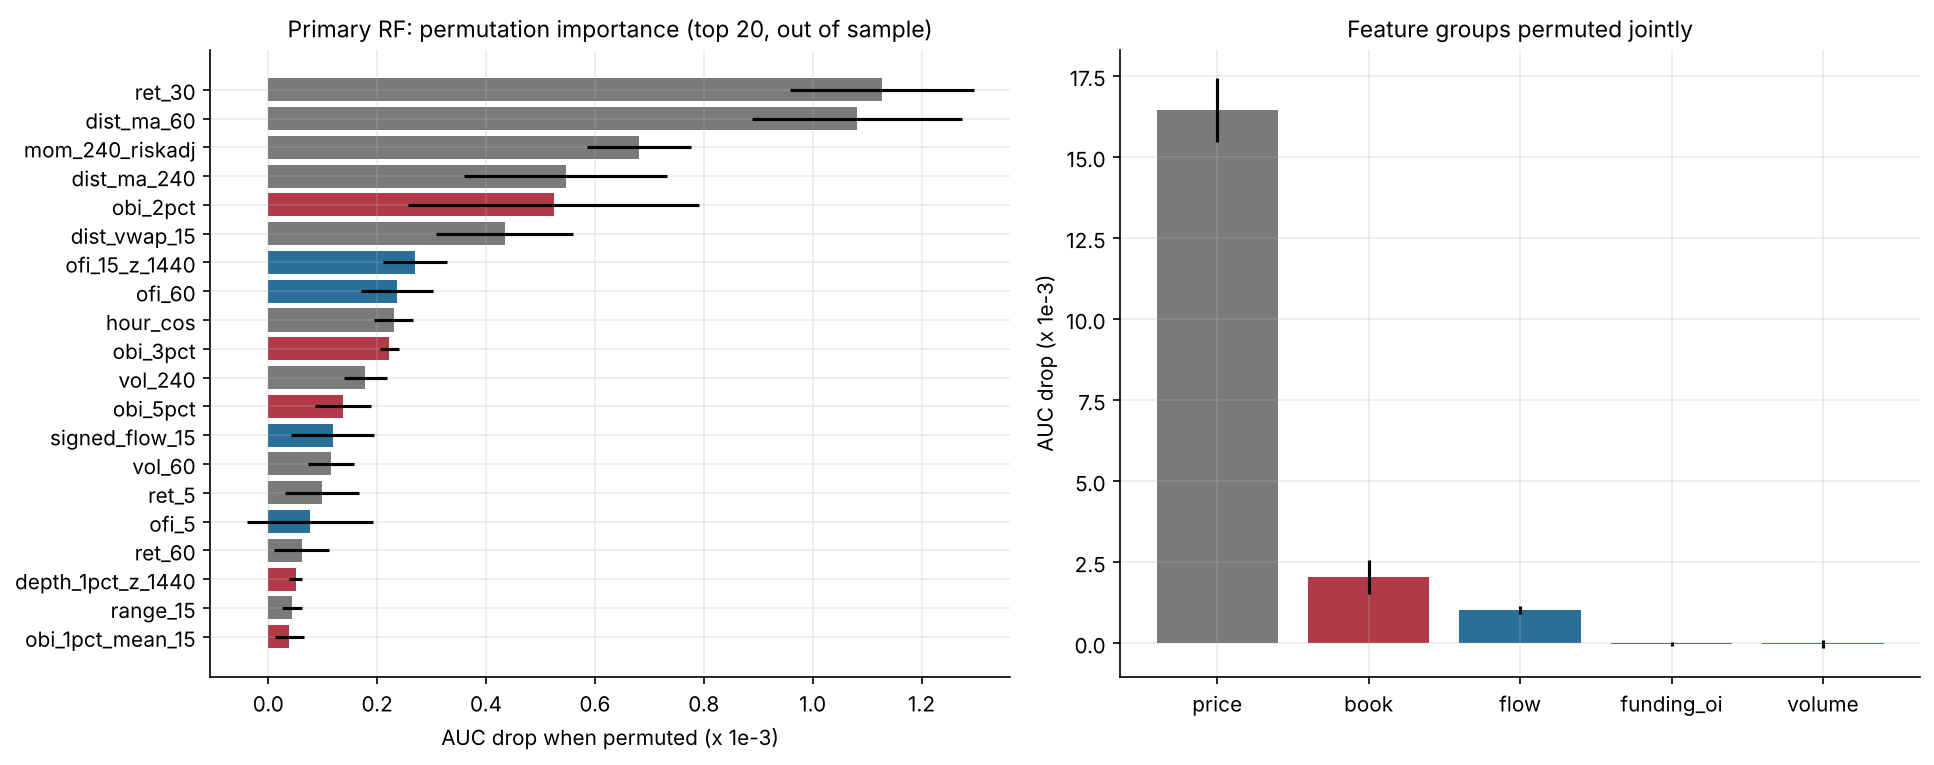

group,n_features,perm_auc_drop,perm_auc_drop_sd,perm_logloss_increase
str,i64,f64,f64,f64
"""price""",16,0.016439,0.000991,0.001444
"""book""",7,0.002042,0.000533,-0.000024
"""flow""",13,0.001025,0.000115,-0.000051
"""funding_oi""",5,-0.00003,0.000052,-0.000005
"""volume""",6,-0.000036,0.00012,-0.00002


In [6]:
show(F / 'interpret/permutation_importance.png'); tab(T / 'interpret_group_permutation.csv')

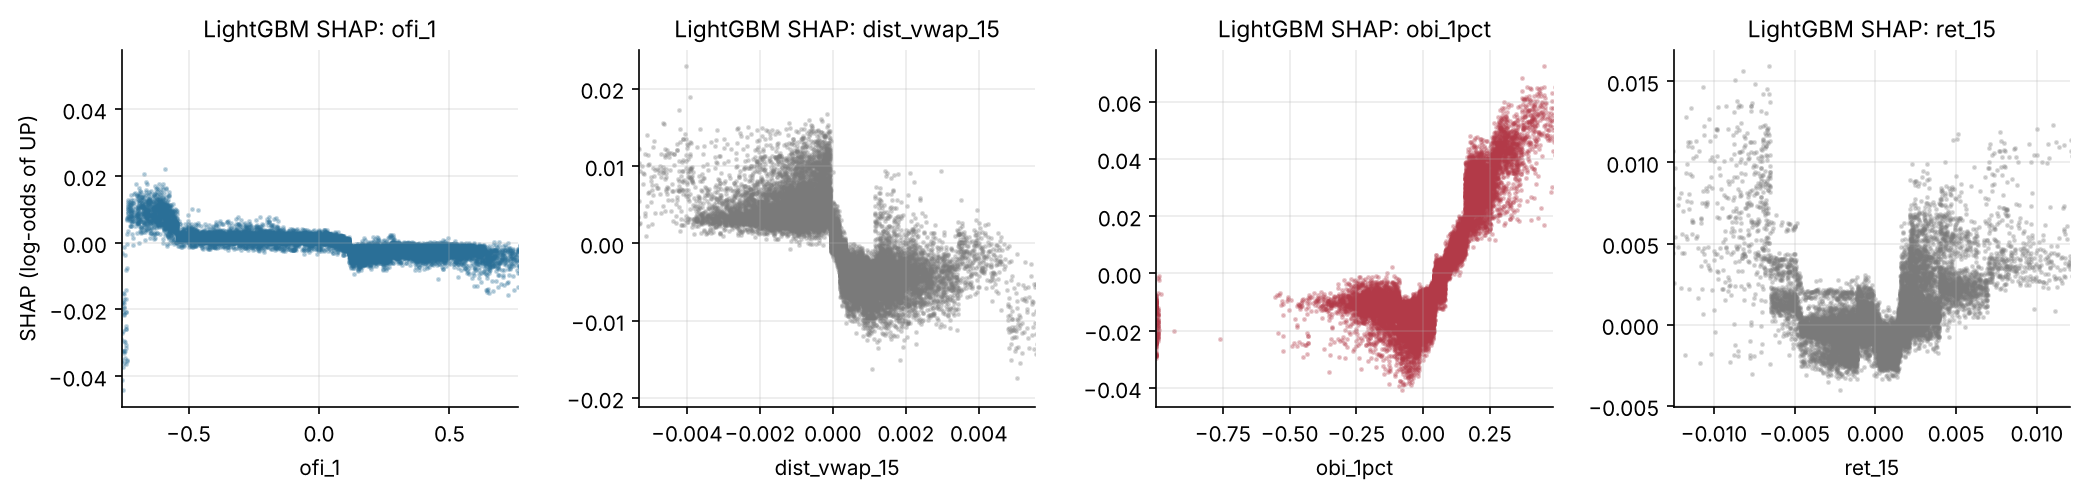

feature,group,gain,gain_share,perm_auc_drop,perm_auc_drop_sd,perm_logloss_increase,rf_impurity_importance,mean_abs_shap
str,str,f64,f64,f64,f64,f64,f64,f64
"""ret_30""","""price""",812.109647,0.014433,0.001127,0.000169,-0.000082,0.055906,0.006881
"""dist_ma_60""","""price""",6070.094251,0.107876,0.001082,0.000193,-0.00021,0.068269,0.043509
"""mom_240_riskadj""","""price""",2006.283119,0.035655,0.000681,0.000095,-0.000004,0.035422,0.01238
"""dist_ma_240""","""price""",7040.971595,0.12513,0.000547,0.000187,-0.000126,0.05653,0.046956
"""obi_2pct""","""book""",2555.492661,0.045416,0.000524,0.000267,-0.000075,0.044347,0.020192
"""dist_vwap_15""","""price""",509.892262,0.009062,0.000434,0.000126,-0.000171,0.053134,0.004389
"""ofi_15_z_1440""","""flow""",184.67728,0.003282,0.00027,0.000059,-0.000017,0.018535,0.000955
"""ofi_60""","""flow""",1358.079667,0.024135,0.000236,0.000066,-0.000047,0.024747,0.008887
"""hour_cos""","""price""",2267.815047,0.040303,0.00023,0.000036,0.000037,0.012731,0.013324


In [7]:
show(F / 'interpret/shap_dependence.png'); tab(T / 'interpret_feature_importance.csv').head(15)